In [234]:
!pip3 install pandas keras tensorflow scikit-learn matplotlib seaborn

19322.50s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable


In [112]:
# Load the dataset CSV file
# Format: 
#   filename - original stl file name, for tracking
#   d - distance to object in mm
#   o - distance between cameras in mm
#   rx, ry, rz - rotation angles in degrees
#   left - path to left image
#  right - path to right image
dataset_file = './stl_data/base_hanan_3_permuted_output/256x256/base_hanan_3_permuted.csv'

# Set the image size for loading images & building the neural network model
IMAGE_SIZE = (256, 256)

# The learning rate for the optimizer
LEARNING_RATE = 1e-3

# Model - the model to use
MODEL = 'naive' # Options: 'naive', 'stereo', 'double_resnet'


X (merged L+R stereo images) shape: (291, 256, 256, 2)
y (distance d) shape: (291,)


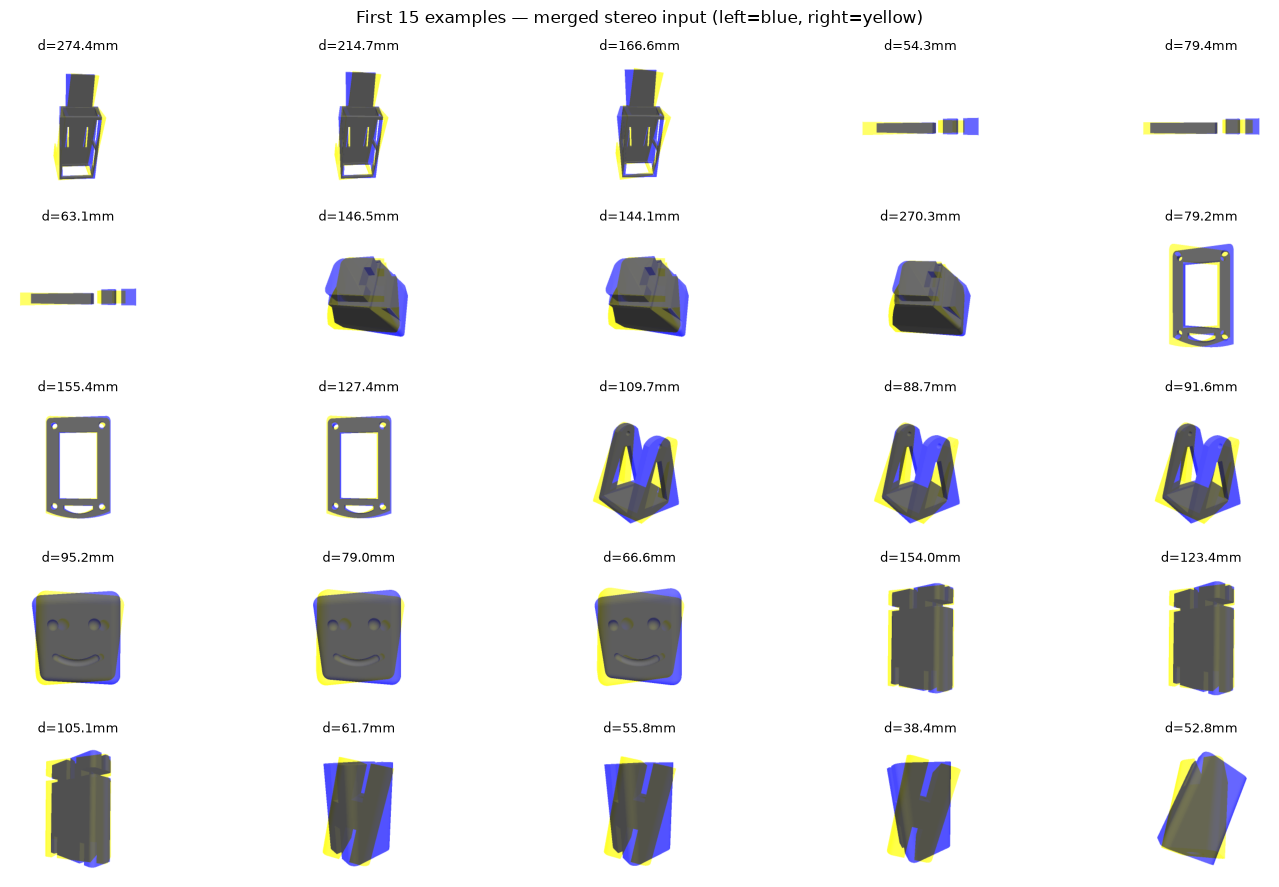

In [113]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
df = pd.read_csv(dataset_file)
dataset_path = os.path.dirname(dataset_file)

# The source renders are single-channel grayscale (mode "L"), not RGB.
# Merge each stereo pair into one 2-channel image: channel 0 = left, channel 1 = right.
# This is early fusion (approach B): the network sees L and R as two dimensions of
# ONE input, the same way an RGB image's 3 channels are treated as one input.
left_imgs, right_imgs, d_values = [], [], []
missing_files = []

for _, row in df.iterrows():
    left_path = os.path.join(dataset_path, row["left"])
    right_path = os.path.join(dataset_path, row["right"])

    if not os.path.exists(left_path) or not os.path.exists(right_path):
        missing_files.append((left_path, right_path))
        continue

    left_imgs.append(np.asarray(Image.open(left_path).convert("L")))
    right_imgs.append(np.asarray(Image.open(right_path).convert("L")))
    d_values.append(row["d"])

if missing_files:
    print(f"{len(missing_files)} missing image files for some rows:", missing_files)
    raise FileNotFoundError("Dataset is corrupt; Some image files are missing. Please check the paths.")

X = np.stack([np.stack([l, r], axis=-1) for l, r in zip(left_imgs, right_imgs)])
y = np.array(d_values, dtype="float32")

print(f"X (merged L+R stereo images) shape: {X.shape}")
print(f"y (distance d) shape: {y.shape}")

# Visualize the first 25 examples. The 2-channel data isn't directly viewable as an
# image, so for display only: left channel -> blue, right channel -> yellow.
n_show = 25
fig, axes = plt.subplots(5, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat[:n_show]):
    left_norm = X[i, :, :, 0].astype("float32") / 255.0
    right_norm = X[i, :, :, 1].astype("float32") / 255.0
    vis = np.stack([right_norm, right_norm, left_norm], axis=-1)  # yellow = R+G, blue = B
    ax.imshow(vis)
    ax.set_title(f"d={y[i]:.1f}mm", fontsize=9)
    ax.axis("off")
plt.suptitle("First 15 examples — merged stereo input (left=blue, right=yellow)")
plt.tight_layout()
plt.show()

In [114]:
# Build the neural network model, and output the model summary

import tensorflow as tf
input_shape = IMAGE_SIZE + (2,)

# NAIVE
def naive_model_builder(input_tensor):
    x = tf.keras.layers.Conv2D(32, 7, activation="relu", padding="same")(input_tensor)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Conv2D(16, 5, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Flatten()(x) 
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    x = tf.keras.layers.Dense(1, activation="linear", name = "d")(x)
    return x

# STEREO_BRANCHES
def stereo_branches_model_builder(input_tensor):
    left = tf.keras.layers.Lambda(lambda x: x[..., 0:1], name="left_channel")(input_tensor)
    right = tf.keras.layers.Lambda(lambda x: x[..., 1:2], name="right_channel")(input_tensor)

    def branch(x):
        x = tf.keras.layers.Conv2D(32, 7, activation="relu", padding="same")(x)
        x = tf.keras.layers.MaxPool2D(2)(x)
        x = tf.keras.layers.Conv2D(16, 5, activation="relu", padding="same")(x)
        x = tf.keras.layers.MaxPool2D(2)(x)
        x = tf.keras.layers.Flatten()(x)
        return x

    left_feat = branch(left)
    right_feat = branch(right)

    merged = tf.keras.layers.Concatenate(name="merge_stereo")([left_feat, right_feat])
    x = tf.keras.layers.Dense(32, activation="relu")(merged)
    x = tf.keras.layers.Dense(1, activation="linear", name="d")(x)
    return x

# DOUBLE_RESNET
def double_resnet_model_builder(input_tensor):
    # Extract left and right channels from the input tensor, and repeat them to create
    # 3-channel images for ResNet50
    left = tf.keras.layers.Lambda(lambda x: x[..., 0:1], name="left_channel")(input_tensor)
    right = tf.keras.layers.Lambda(lambda x: x[..., 1:2], name="right_channel")(input_tensor)
    left = tf.keras.layers.RepeatVector(3)(tf.keras.layers.Flatten()(left))
    left = tf.keras.layers.Reshape((256, 256, 3))(left)
    right = tf.keras.layers.RepeatVector(3)(tf.keras.layers.Flatten()(right))
    right = tf.keras.layers.Reshape((256, 256, 3))(right)

    # Use a pre-trained ResNet50 model to extract features from the left and right images
    feature_ext = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=(256, 256, 3), pooling=None)
    left_features = feature_ext(left)
    right_features = feature_ext(right)
    correlation = left_features * right_features
    difference = left_features - right_features
    x = tf.keras.layers.Concatenate(axis=-1)([correlation, difference])

    # Add additional convolutional layers to process the combined features
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Add fully connected layers to predict the distance
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    output_d = tf.keras.layers.Dense(1, activation="linear", name="d")(x)
    return output_d

# Prepare the input layer for the model, which will accept 2-channel images of the specified input shape
input_image = tf.keras.Input(shape=input_shape, name="image_stereo")

# Build the model based on the selected architecture
model_builder = globals()[f"{MODEL}_model_builder"]
output_d = model_builder(input_image)

model = tf.keras.Model(inputs=input_image, outputs=output_d)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss="mse", )

model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_stereo (InputLayer)       │ (None, 256, 256, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 256, 256, 32)   │         3,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 128, 128, 16)   │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │     2,097,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d (Dense)                       │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113,201 (8.06 MB)

 Trainable params: 2,113,201 (8.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# normalize image data for training
adjusted_images = X.astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    adjusted_images, y, test_size=0.2, random_state=42, shuffle=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=20,
    validation_split=0.2,
    shuffle=True,
    verbose=1,
)

Epoch 1/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - loss: 28589.5938 - val_loss: 21641.0918
Epoch 2/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - loss: 16128.6807 - val_loss: 16545.5391
Epoch 3/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 287ms/step - loss: 15411.2578 - val_loss: 18160.7227
Epoch 4/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step - loss: 15360.1201 - val_loss: 16071.6396
Epoch 5/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - loss: 13155.5273 - val_loss: 18319.2227
Epoch 6/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 307ms/step - loss: 16124.0010 - val_loss: 17653.0410
Epoch 7/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step - loss: 14024.3652 - val_loss: 14790.6826
Epoch 8/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step - loss: 12697.1104 - val_loss: 14453.6201
Epoch 9/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - loss: 10799.7500 - val_loss: 15051.1436
Epoch 10/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step - loss: 10305.1172 - val_loss: 15058.0029
Epoch 11/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step - loss

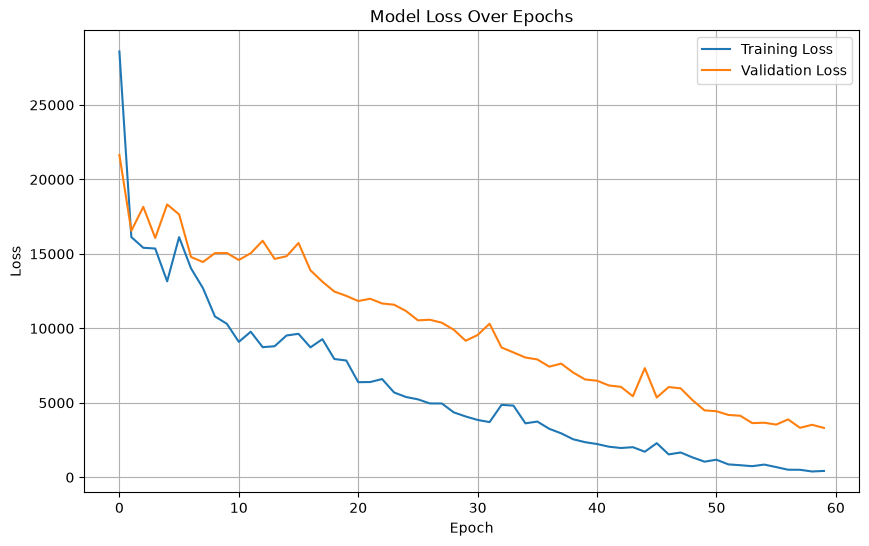

In [116]:
# Plot the training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [118]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


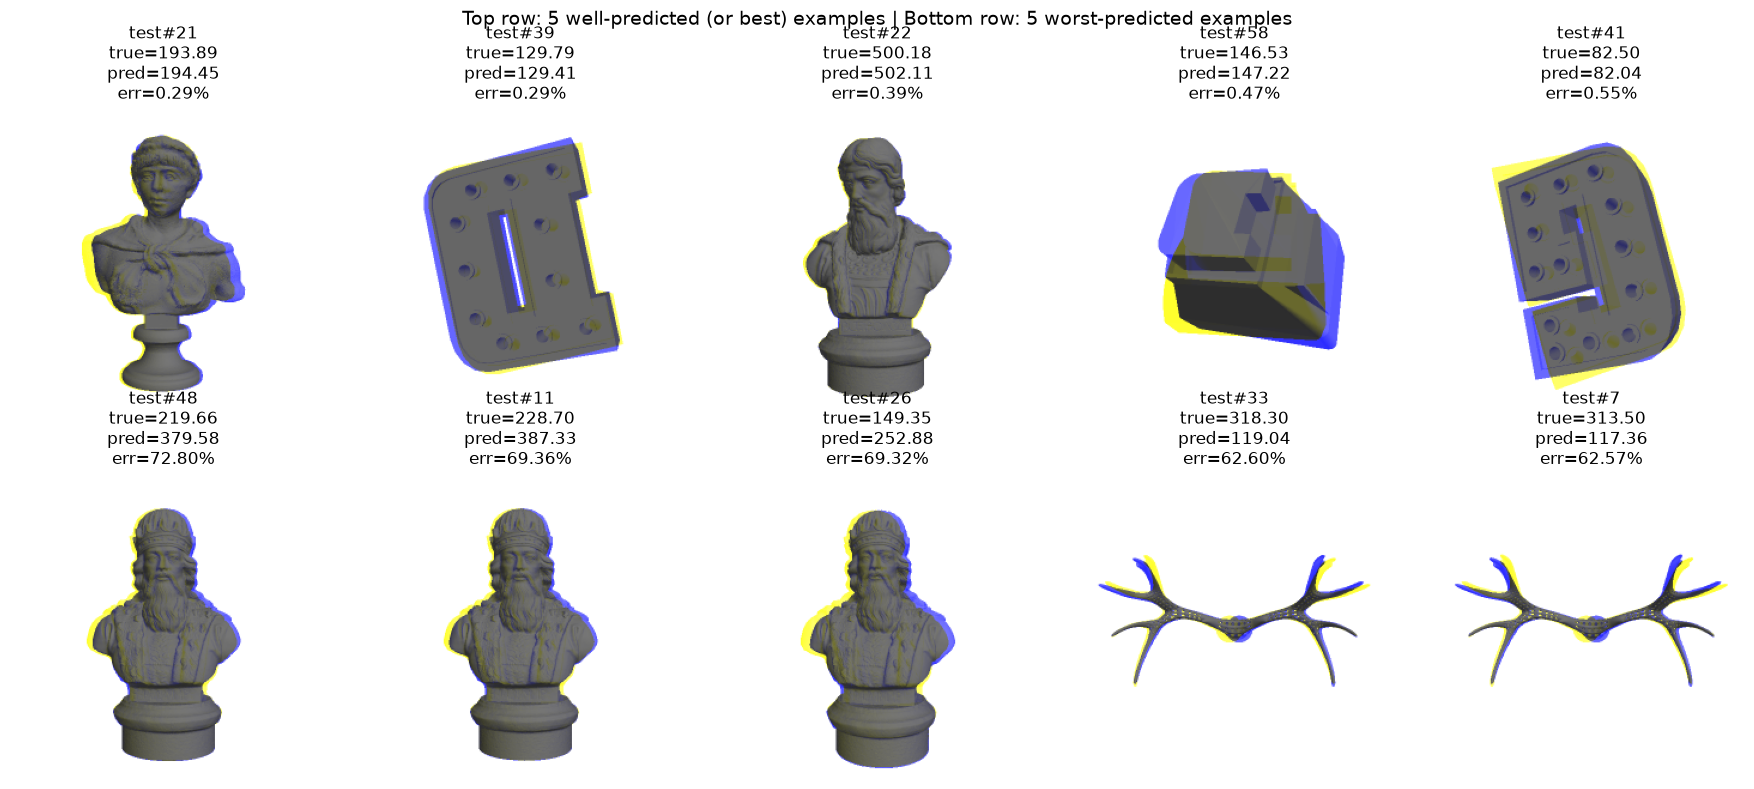

In [119]:
import numpy as np

# Select and display 5 well-predicted (<5% error) and 5 worst-predicted test examples.
import matplotlib.pyplot as plt

# Predict the depth values for the test set
y_pred = model.predict(X_test, verbose=0).reshape(-1)

# ensure flattened
y_pred_arr = np.asarray(y_pred).flatten()
y_test_arr = np.asarray(y_test).flatten()

# percentage absolute error (guard against division by zero)
eps = 1e-6
pct_err = np.abs(y_pred_arr - y_test_arr) / np.maximum(np.abs(y_test_arr), eps)

# sorted indices by error
sorted_idx = np.argsort(pct_err)
# well-predicted indices (error < 5%)
well_mask = pct_err < 0.05
well_candidates = sorted_idx[well_mask[sorted_idx]]
# pick up to 5 from true <5% set, fill with best remaining if fewer
n_well = 5
well_idx = list(well_candidates[:n_well])
if len(well_idx) < n_well:
    for idx in sorted_idx:
        if idx not in well_idx:
            well_idx.append(idx)
        if len(well_idx) == n_well:
            break

# worst 5 (largest pct error)
worst_idx = list(np.argsort(pct_err)[-5:][::-1])

# display
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for col, idx in enumerate(well_idx):
    left = X_test[idx, :, :, 0]
    right = X_test[idx, :, :, 1]
    vis = np.stack([right, right, left], axis=-1)
    ax = axes[0, col]
    ax.imshow(vis)
    ax.set_title(f"test#{idx}\ntrue={y_test_arr[idx]:.2f}\npred={y_pred_arr[idx]:.2f}\nerr={pct_err[idx]*100:.2f}%")
    ax.axis("off")

for col, idx in enumerate(worst_idx):
    left = X_test[idx, :, :, 0]
    right = X_test[idx, :, :, 1]
    vis = np.stack([right, right, left], axis=-1)
    ax = axes[1, col]
    ax.imshow(vis)
    ax.set_title(f"test#{idx}\ntrue={y_test_arr[idx]:.2f}\npred={y_pred_arr[idx]:.2f}\nerr={pct_err[idx]*100:.2f}%")
    ax.axis("off")

plt.suptitle("Top row: 5 well-predicted (or best) examples | Bottom row: 5 worst-predicted examples", fontsize=14)
plt.tight_layout()
plt.show()

Test RMSE: 74.4368


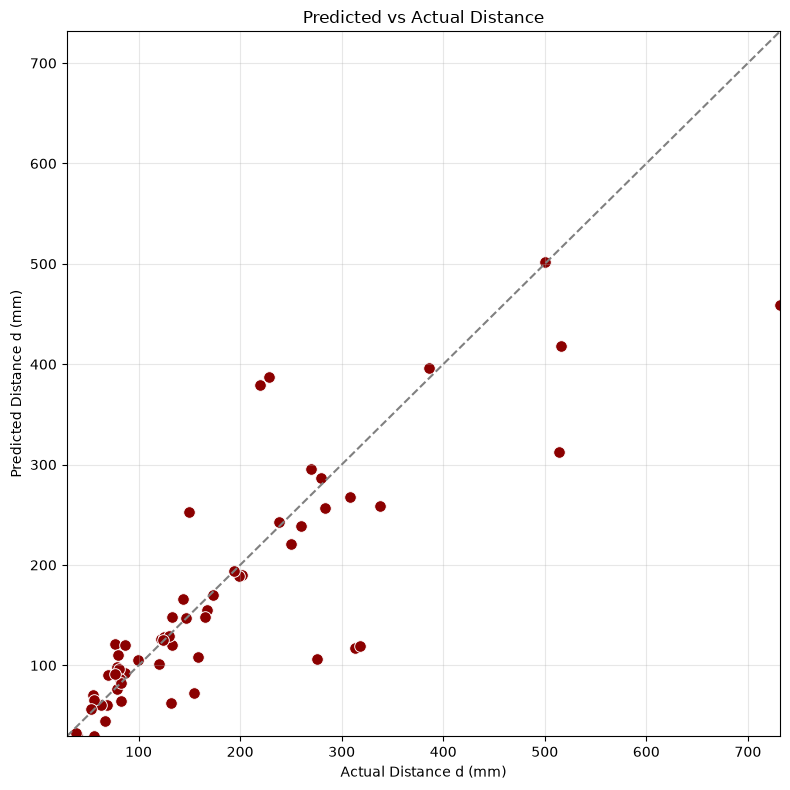

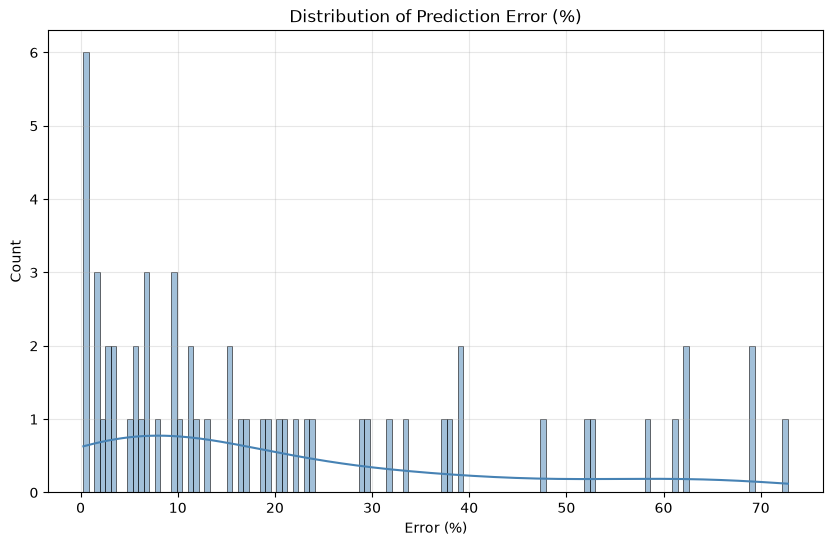

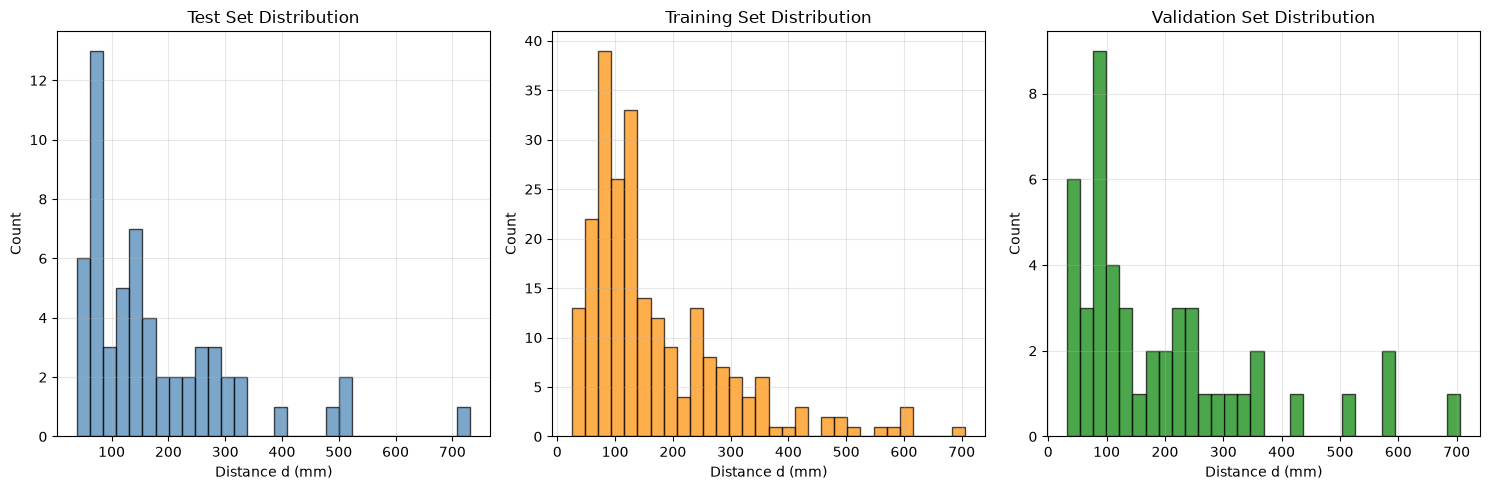

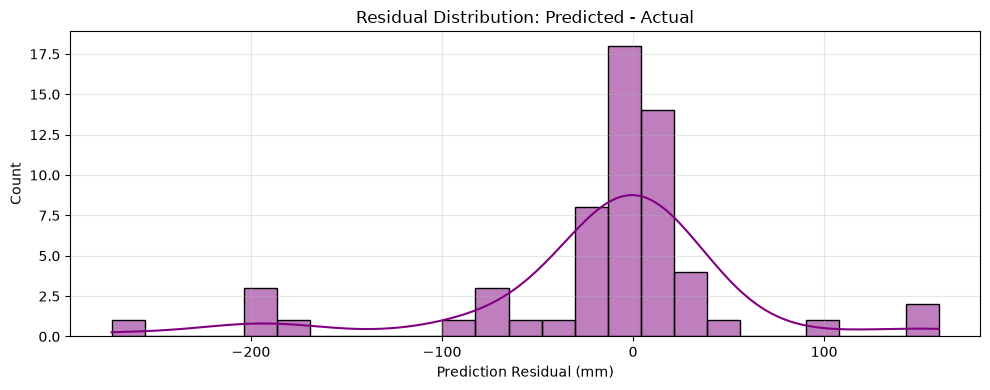

In [123]:
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
print(f"Test RMSE: {rmse:.4f}")

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test_arr, y=y_pred_arr, color="darkred", s=70, edgecolor="white")
min_val = min(y_test_arr.min(), y_pred_arr.min())
max_val = max(y_test_arr.max(), y_pred_arr.max())
plt.plot([min_val, max_val], [min_val, max_val], "--", color="gray", linewidth=1.5)
plt.xlabel("Actual Distance d (mm)")
plt.ylabel("Predicted Distance d (mm)")
plt.title("Predicted vs Actual Distance")
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

error_pct = pct_err * 100

plt.figure(figsize=(10, 6))
sns.histplot(error_pct, bins=128, kde=True, color="steelblue")
plt.xlabel("Error (%)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Error (%)")
plt.grid(True, alpha=0.3)
plt.show()



# Create a figure with subplots for test, training, and validation distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Test set distribution
axes[0].hist(y_test, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Distance d (mm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Test Set Distribution')
axes[0].grid(True, alpha=0.3)

# Training set distribution
axes[1].hist(y_train, bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Distance d (mm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Training Set Distribution')
axes[1].grid(True, alpha=0.3)

# Validation set distribution (extracted from training data)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, shuffle=True
)
axes[2].hist(y_val_split, bins=30, color='green', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Distance d (mm)')
axes[2].set_ylabel('Count')
axes[2].set_title('Validation Set Distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 4))
residuals = y_pred_arr - y_test_arr
sns.histplot(residuals, bins=25, kde=True, color="purple")
plt.xlabel("Prediction Residual (mm)")
plt.title("Residual Distribution: Predicted - Actual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

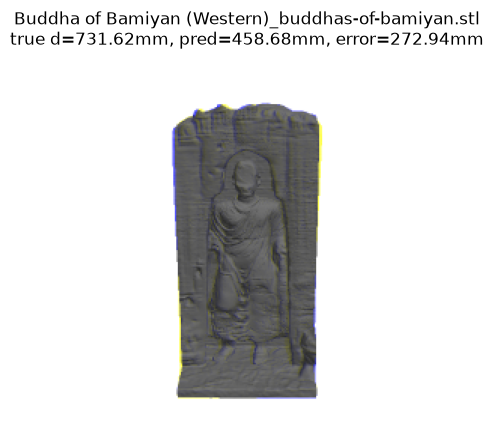

Worst prediction: test index 53 (CSV row 174)
  filename: Buddha of Bamiyan (Western)_buddhas-of-bamiyan.stl
  true d:      731.62 mm
  predicted d: 458.68 mm
  abs error:   272.94 mm
  rotation: rx=-71.0, ry=0.0, rz=0


In [124]:
# Find the single test example with the largest prediction error and show it,
# along with which original STL/CSV row it came from.
abs_err = np.abs(y_pred_arr - y_test_arr)
outlier_idx = np.argmax(abs_err)

# Recover the original df row for this test example: re-running the identical
# split (same random_state, same length) on plain row indices reproduces the
# exact same train/test partition, so it maps X_test's position back to the
# source CSV row without having to thread an index/filename array through
# every earlier cell.
indices = np.arange(len(y))
_, test_indices = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)
orig_row = df.iloc[test_indices[outlier_idx]]

left = X_test[outlier_idx, :, :, 0]
right = X_test[outlier_idx, :, :, 1]
vis = np.stack([right, right, left], axis=-1)

plt.figure(figsize=(5, 5))
plt.imshow(vis)
plt.axis("off")
plt.title(
    f"{orig_row['filename']}\n"
    f"true d={y_test_arr[outlier_idx]:.2f}mm, pred={y_pred_arr[outlier_idx]:.2f}mm, "
    f"error={abs_err[outlier_idx]:.2f}mm"
)
plt.show()

print(f"Worst prediction: test index {outlier_idx} (CSV row {test_indices[outlier_idx] + 2})")
print(f"  filename: {orig_row['filename']}")
print(f"  true d:      {y_test_arr[outlier_idx]:.2f} mm")
print(f"  predicted d: {y_pred_arr[outlier_idx]:.2f} mm")
print(f"  abs error:   {abs_err[outlier_idx]:.2f} mm")
print(f"  rotation: rx={orig_row['rx']}, ry={orig_row['ry']}, rz={orig_row['rz']}")